# InSituPy demonstration - Performance tests

In [1]:
## The following code ensures that all functions and init files are reloaded before executions.
%load_ext autoreload
%autoreload 2

In [2]:
import shutil
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from insitupy import CACHE, InSituData
from insitupy.palettes import CustomPalettes

In [3]:
palettes = CustomPalettes()

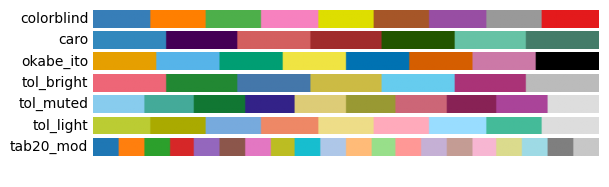

In [4]:
palettes.show_all()

## Load Xenium data into `InSituData` object

In [5]:
insitupy_project = Path(CACHE / "out/demo_insitupy_project")

In [6]:
xd = InSituData.read(insitupy_project)

In [7]:
xd.load_all()

C:\Users\ge37voy\Github\InSituPy\insitupy\dataclasses\io.py:230: UserWarning: No 'color' column found in the imported data. Setting all colors to red.
  data.add_data(data=f, key=k,
C:\Users\ge37voy\Github\InSituPy\insitupy\dataclasses\io.py:230: UserWarning: No 'color' column found in the imported data. Setting all colors to red.
  data.add_data(data=f, key=k,
C:\Users\ge37voy\Github\InSituPy\insitupy\dataclasses\io.py:230: UserWarning: No 'color' column found in the imported data. Setting all colors to red.
  data.add_data(data=f, key=k,
C:\Users\ge37voy\Github\InSituPy\insitupy\dataclasses\io.py:230: UserWarning: No 'color' column found in the imported data. Setting all colors to red.
  data.add_data(data=f, key=k,


## Test writing data to disk

In [8]:
pixel_size = xd.images.metadata["nuclei"]["pixel_size"]
shape_um = tuple([elem * pixel_size for elem in xd.images["nuclei"][0].shape])
center = tuple([int(elem / 2) for elem in shape_um])

### Test `.saveas` and `.save`

In [9]:
# parameters
square_width_list = [4000, 2000, 1000, 500, 250]
n_replicates = 3
out_dir = Path("./out")

dt_list_saveas = []
dt_list_save = []
for _ in range(n_replicates):
    # delete existing output directories
    if out_dir.exists():
        print("Delete existing output directory...")
        shutil.rmtree(out_dir)

    print("TEST SAVING OF BOTH STATIC AND VARIABLE DATA...")
    # test saving with `saveas` (both variable and static data)
    dt_list_saveas.append([])
    for square_width in square_width_list:
        t0 = datetime.now()
        xlim = (int(center[1] - square_width / 2), int(center[1] + square_width / 2))
        ylim = (int(center[0] - square_width / 2), int(center[0] + square_width / 2))

        # crop data
        xd_cropped = xd.crop(xlim=xlim, ylim=ylim)

        # save data
        xd_cropped.saveas(out_dir / f"crop{square_width}")
        t1 = datetime.now()
        dt_list_saveas[-1].append(t1 - t0)

    print("TEST SAVING OF VARIABLE DATA ONLY...")
    # test saving with `save` (only variable data)
    dt_list_save.append([])
    for square_width in square_width_list:
        # load the data
        data = InSituData.read(out_dir / f"crop{square_width}")
        data.load_all()

        # measure time to save the variable data only
        t0 = datetime.now()
        data.save()
        t1 = datetime.now()
        dt_list_save[-1].append(t1 - t0)

Delete existing output directory...
TEST SAVING OF BOTH STATIC AND VARIABLE DATA...
Saving data to out\crop4000
Saved.
Saving data to out\crop2000
Saved.
Saving data to out\crop1000
Saved.
Saving data to out\crop500
Saved.
Saving data to out\crop250
Saved.
TEST SAVING OF VARIABLE DATA ONLY...
Saving to existing path: out\crop4000
Updating project in out\crop4000
	Updating cells...
	Updating annotations...
	Updating regions...
Saved.
Saving to existing path: out\crop2000
Updating project in out\crop2000
	Updating cells...
	Updating annotations...
	Updating regions...
Saved.
Saving to existing path: out\crop1000
Updating project in out\crop1000
	Updating cells...
	Updating annotations...
	Updating regions...
Saved.
Saving to existing path: out\crop500
Updating project in out\crop500
	Updating cells...
	Updating annotations...
	Updating regions...
Saved.
Saving to existing path: out\crop250
Updating project in out\crop250
	Updating cells...
	Updating annotations...
	Updating regions...
Sa

In [10]:
dt_list_saveas_sec = [[elem.total_seconds() for elem in l] for l in dt_list_saveas]
dt_list_save_sec = [[elem.total_seconds() for elem in l] for l in dt_list_save]

In [11]:
df_saveas = pd.DataFrame(dt_list_saveas_sec, columns=square_width_list).T
df_save = pd.DataFrame(dt_list_save_sec, columns=square_width_list).T
df_saveas = df_saveas.reset_index(names="Square width [µm]").melt(id_vars="Square width [µm]", var_name="Replicates", value_name="Time [s]")
df_save = df_save.reset_index(names="Square width [µm]").melt(id_vars="Square width [µm]", var_name="Replicates", value_name="Time [s]")

In [12]:
figure_dir = Path("figures")
figure_dir.mkdir(exist_ok=True)

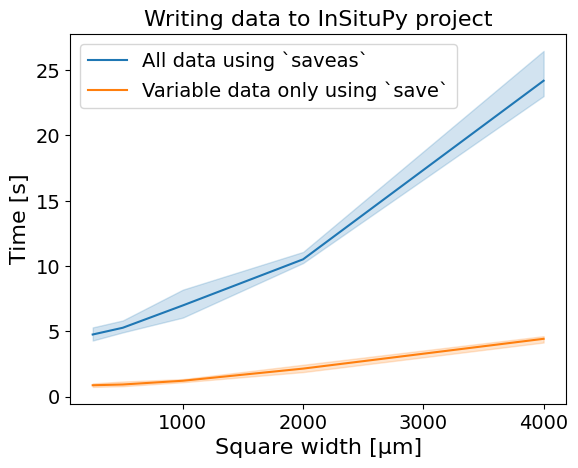

In [13]:
sns.lineplot(df_saveas, x="Square width [µm]", y="Time [s]", label="All data using `saveas`")
sns.lineplot(df_save, x="Square width [µm]", y="Time [s]", label="Variable data only using `save`")
plt.title("Writing data to InSituPy project")
plt.legend()
plt.savefig(figure_dir / "lineplot_performance_write.pdf")
plt.show()

## Loading performance

In [22]:
dt_names = ["Metadata", "Images", "Cells", "Transcripts", "Annotations", "Regions"]
dt_list_load = []
for square_width in square_width_list:
    path = out_dir / f"crop{square_width}"
    t_list = [datetime.now()]
    xd = InSituData.read(path)
    t_list.append(datetime.now())
    xd.load_images()
    t_list.append(datetime.now())
    xd.load_cells()
    t_list.append(datetime.now())
    xd.load_transcripts()
    t_list.append(datetime.now())
    xd.load_annotations()
    t_list.append(datetime.now())
    xd.load_regions()
    t_list.append(datetime.now())

    # save results
    dt_list = [t_list[i+1] - t_list[i] for i in range(len(t_list)-1)]
    dt_list = [elem.total_seconds() for elem in dt_list]
    dt_list_load.append(dt_list)

In [23]:
df_load = pd.DataFrame(dt_list_load, index=square_width_list, columns=dt_names).reset_index(names="Square width [µm]")
df_load = df_load.sort_values("Square width [µm]")
df_load = df_load.drop("Metadata", axis=1)
df_load_melt = df_load.melt(id_vars="Square width [µm]", var_name="Data type", value_name="Time [s]")

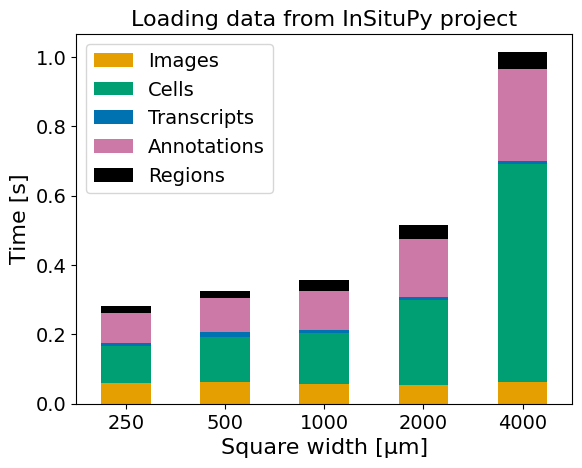

In [24]:
df_load.plot(kind='bar', stacked=True, x="Square width [µm]", colormap=palettes.okabe_ito)
plt.title("Loading data from InSituPy project")
plt.ylabel("Time [s]")
plt.xticks(rotation=0)  # 0 degrees = horizonta
plt.savefig(figure_dir / "barplot_performance_load.pdf", bbox_inches="tight")
plt.show()